In [62]:
# المكتبات الأساسية
import pandas as pd
import numpy as np
import scipy.stats as ss

# التصورات البيانية
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# تحليل الارتباط
from mlxtend.frequent_patterns import apriori, association_rules

# أدوات مساعدة
import itertools 
import collections  
import researchpy
import time
import gc
import os

# إعدادات العرض
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.precision", 3)
pd.options.display.float_format = '{:,.3f}'.format

# تحسين الأداء
begin = time.time()
gc.collect()

40462

In [24]:
df = pd.read_csv('Market_Basket_Optimisation.csv', header=None)
df.head(3)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
df.shape # 7501 Transactions # Max no. of items purchased = 20

(7501, 20)

In [26]:
df.info() # Original dataset has multiple instances as nan as individual transactions might not hold all possible item list

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7501 entries, 0 to 7500
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       7501 non-null   object
 1   1       5747 non-null   object
 2   2       4389 non-null   object
 3   3       3345 non-null   object
 4   4       2529 non-null   object
 5   5       1864 non-null   object
 6   6       1369 non-null   object
 7   7       981 non-null    object
 8   8       654 non-null    object
 9   9       395 non-null    object
 10  10      256 non-null    object
 11  11      154 non-null    object
 12  12      87 non-null     object
 13  13      47 non-null     object
 14  14      25 non-null     object
 15  15      8 non-null      object
 16  16      4 non-null      object
 17  17      4 non-null      object
 18  18      3 non-null      object
 19  19      1 non-null      object
dtypes: object(20)
memory usage: 1.1+ MB


In [27]:
# هذ الكود يقوم بضافة عمليات الشر في مصفوفة  
# بعد تنظيف السجلات الفارغة عرض المنتجات الذي تم شرائها في الصف الثاني
records = []
for i in range(0, df.shape[0]): # Tubleترجع البيانات على شكل .shape[0] 
    records.append([str(df.values[i,j]) for j in range(0, df.shape[1])])
    
print([x for x in records[1] if str(x) != 'nan']) # Second Transaction Data

['burgers', 'meatballs', 'eggs']


In [28]:
# استخراج قائمة فريدة تحتوي على جميع المنتجات الموجودة في البيانات وتخزينها في مصفوفة
unq = []
for col in df.columns:
    unq.append(list(set(df[col].unique().tolist())))
    
flattenItemList = [item for sublist in unq for item in sublist]

In [29]:
# يقوم بطباعة المنتجات المكررة فقط (التي تظهر أكثر من مرة)
print([item for item, count in collections.Counter(flattenItemList).items() if count > 1])

['salad', 'vegetables mix', 'brownies', 'tomatoes', 'shallot', 'low fat yogurt', 'hand protein bar', 'whole weat flour', 'flax seed', 'tomato sauce', 'ham', 'green beans', 'meatballs', 'milk', 'oil', 'salt', 'corn', 'cauliflower', 'spinach', 'cottage cheese', 'tomato juice', 'barbecue sauce', 'mint green tea', 'grated cheese', 'dessert wine', 'cider', 'cooking oil', 'light mayo', 'antioxydant juice', 'cream', 'shampoo', 'babies food', 'blueberries', 'fresh tuna', 'rice', 'oatmeal', 'energy drink', 'mashed potato', 'olive oil', 'avocado', 'cake', 'hot dogs', 'muffins', 'gums', 'pancakes', 'bramble', 'pet food', 'protein bar', 'bacon', 'sandwich', 'toothpaste', 'escalope', 'bug spray', 'burger sauce', 'cereals', 'eggs', 'honey', 'french wine', 'mushroom cream sauce', 'burgers', 'cookies', 'fresh bread', 'red wine', 'green grapes', 'candy bars', 'extra dark chocolate', 'whole wheat rice', 'butter', 'sparkling water', 'turkey', 'spaghetti', 'clothes accessories', 'yogurt cake', 'energy bar

In [30]:
#ستخراج قائمة بالمنتجات الفريدة فقط (بدون تكرار) من جميع البيانات لبناء جدول ثنائي للمعاملات.

uniqueItems = list(set(flattenItemList)) # extracting only the unique items for building the DataFrame of transactions
uniqueItems[10] #طباعة العنصر رقم 10

'tomato sauce'

In [31]:
#يقوم بتنظيف قائمة المنتجات الفارغة ثم طباعة عدد المنتجات بدون تكرار
uniqueItems = [x for x in uniqueItems if str(x) != 'nan'] # datasets contained 'nan' as string
len(uniqueItems)

120

In [32]:
%%time
def buildDataset(df, uniqueItems):
    """
   Aprioriتحويل بيانات سلة التسوق من تنسيق عريض إلى تنسيق ثنائي مناسب لخوارزمية . 
اي يقوم بنشاء جدول يحتوي على اصفار واحد 
رقم واحد يعني ان المنتج تم بيعة في صف المعاملة المحددة لة 
رقم 0 يعني ان المنتج لم يتم شرائة 
الكود يحول بيانات المتجر إلى لغة تفهمها خوارزميات الذكاء الاصطناعي
لكتشاف قواعد الارتباط
هذا الكود يعتبر مهم جدا
    
    """
    dfCleaned = pd.DataFrame(np.zeros((df.shape[0], len(uniqueItems))), columns=uniqueItems, dtype=np.int32)
    
    for colIdx, item in enumerate(dfCleaned.columns.tolist()): # Take one column at a time
        for rowIdx, row in df.iterrows(): # Take items from the first row
            rowVals = row.values # Compare with uniqueItems
            if item in rowVals:
                dfCleaned.iloc[rowIdx, colIdx] = 1
            
    return dfCleaned

df = buildDataset(df, uniqueItems)
df.head(3)



CPU times: total: 1min 11s
Wall time: 1min 23s


,salad,vegetables mix,brownies,tomatoes,shallot,low fat yogurt,hand protein bar,whole weat flour,flax seed,tomato sauce,ham,green beans,meatballs,milk,oil,salt,corn,cauliflower,spinach,cottage cheese,tomato juice,barbecue sauce,mint green tea,grated cheese,dessert wine,cider,cooking oil,light mayo,antioxydant juice,cream,shampoo,babies food,blueberries,fresh tuna,rice,asparagus,oatmeal,energy drink,mashed potato,olive oil,avocado,cake,hot dogs,muffins,water spray,gums,pancakes,bramble,pet food,protein bar,bacon,sandwich,toothpaste,escalope,bug spray,burger sauce,cereals,eggs,zucchini,honey,french wine,mushroom cream sauce,burgers,cookies,fresh bread,red wine,tea,green grapes,candy bars,extra dark chocolate,whole wheat rice,butter,sparkling water,turkey,spaghetti,clothes accessories,napkins,yogurt cake,energy bar,pickles,strong cheese,shrimp,mineral water,light cream,parmesan cheese,frozen smoothie,champagne,chutney,pepper,herb & pepper,melons,whole wheat pasta,chocolate bread,almonds,pasta,ground beef,chili,soda,frozen vegetables,french fries,green tea,gluten free bar,magazines,body spray,nonfat milk,black tea,ketchup,strawberries,chocolate,chicken,yams,eggplant,asparagus,carrots,soup,salmon,white wine,mayonnaise,mint,fromage blanc
0,1,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [33]:
# يقوم بحساب عدد مرات شراء كل منتج 
# مناسب لتسويق  حيث من خلال هذا التحليل يستطيع البائع على
# ترتيب المنتجات: وضع الأكثر مبيعًا في أماظهر
# إدارة المخزون: التركيز على المنتجات الشعبية
# العروض الترويجية: تحفيز المنتجات الأقل مبيعًا
df.sum()[:5] 

salad              37
vegetables mix    193
brownies          253
tomatoes          513
shallot            58
dtype: int64

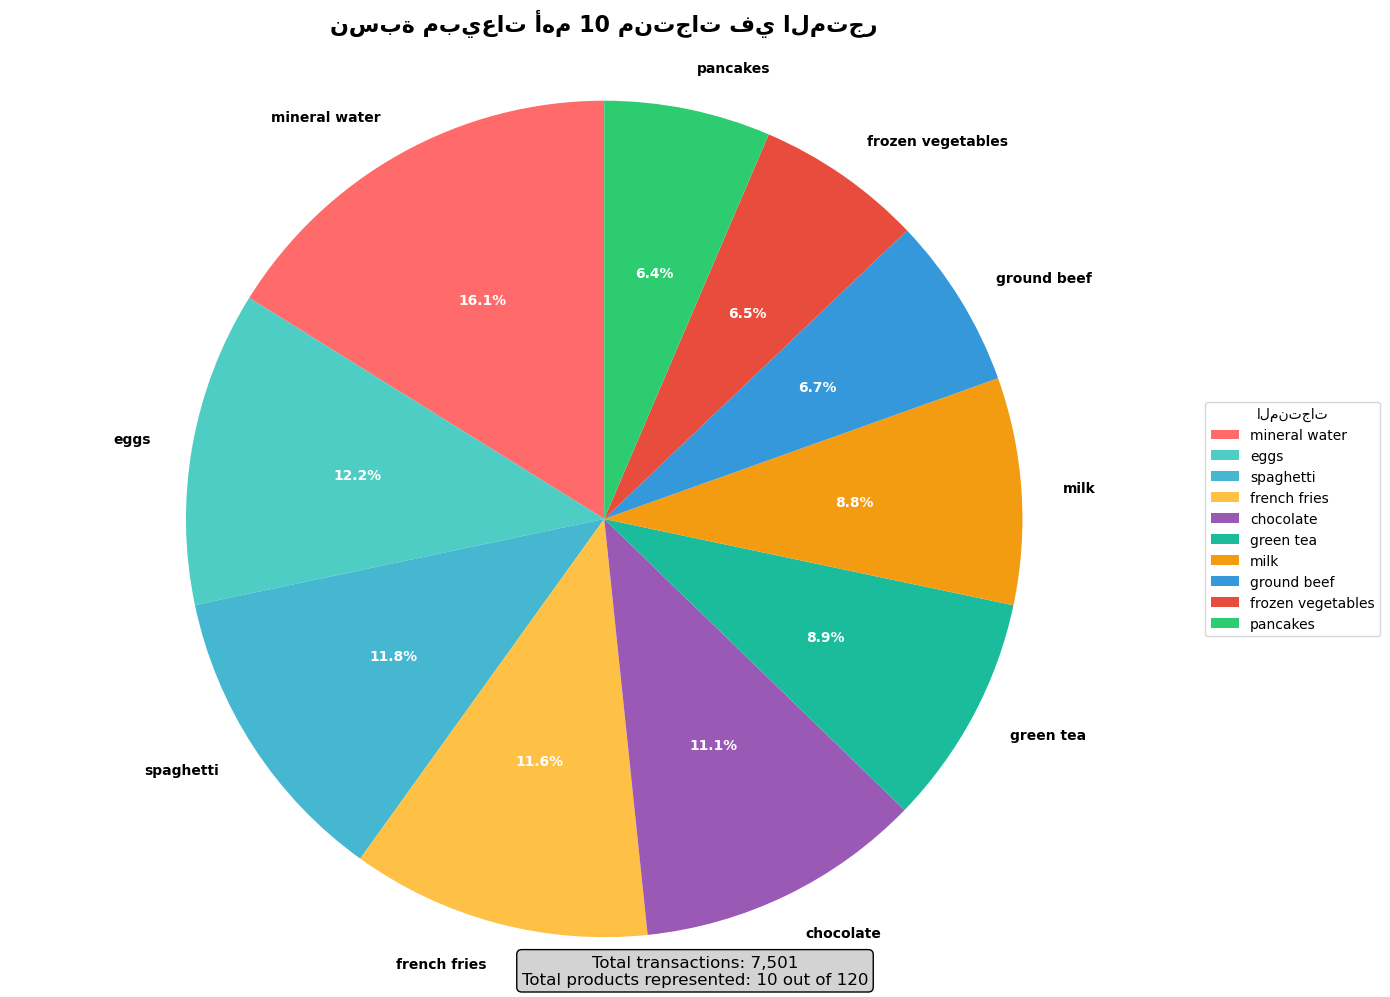

🔍 Digital details of the top 10 products:
1. mineral water: 1,788 عملية شراء (23.8%)
2. eggs: 1,348 عملية شراء (18.0%)
3. spaghetti: 1,306 عملية شراء (17.4%)
4. french fries: 1,282 عملية شراء (17.1%)
5. chocolate: 1,229 عملية شراء (16.4%)
6. green tea: 991 عملية شراء (13.2%)
7. milk: 972 عملية شراء (13.0%)
8. ground beef: 737 عملية شراء (9.8%)
9. frozen vegetables: 715 عملية شراء (9.5%)
10. pancakes: 713 عملية شراء (9.5%)

📊 These ten products represent 37.7% of total purchases


In [34]:
# حساب عدد مرات ظهور كل منتج (التكرارات)
item_occurrences = df.sum()

# ترتيب المنتجات من الأكثر إلى الأقل شيوعاً
item_occurrences_sorted = item_occurrences.sort_values(ascending=False)

# أخذ أفضل 10 منتجات فقط (بدون "منتجات أخرى")
top_10_items = item_occurrences_sorted.head(10)

# الألوان
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFC145', '#9B59B6', 
          '#1ABC9C', '#F39C12', '#3498DB', '#E74C3C', '#2ECC71']

# إنشاء الرسمة الدائرية
plt.figure(figsize=(14, 10))
wedges, texts, autotexts = plt.pie(top_10_items.values, labels=top_10_items.index, 
                                   colors=colors, autopct='%1.1f%%', startangle=90,
                                   textprops={'fontsize': 10, 'fontweight': 'bold'})

# تحسين مظهر النسب المئوية
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

# إضافة عنوان
plt.title('نسبة مبيعات أهم 10 منتجات في المتجر', 
          fontsize=16, fontweight='bold', pad=20)

# ضمان أن الرسمة دائرية
plt.axis('equal')

# إضافة وسيلة إيضاح
plt.legend(top_10_items.index, title="المنتجات", loc="center left", 
           bbox_to_anchor=(1, 0, 0.5, 1))

# إضافة مربع معلومات
plt.figtext(0.5, 0.01, 
            f'Total transactions: {len(df):,}\nTotal products represented: {len(top_10_items)} out of {len(df.columns)}',
            ha='center', fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

plt.tight_layout()
plt.show()

# عرض التفاصيل الرقمية
print("🔍 Digital details of the top 10 products:")
print("="*50)
for i, (item, count) in enumerate(top_10_items.items(), 1):
    percentage = (count / len(df)) * 100
    print(f"{i}. {item}: {count:,} عملية شراء ({percentage:.1f}%)")

# حساب التغطية الإجمالية
total_coverage = top_10_items.sum() / df.sum().sum() * 100
print(f"\n📊 These ten products represent {total_coverage:.1f}% of total purchases")


In [35]:
df.describe().loc[['count', 'mean', 'std']].sort_values(by = 'mean', axis=1, ascending=False) # To check the mean of the items across all 7501 transactions ; 
# spaghetti ; french fries ; eggs ; ground beef ; chocolate ; milk are the most frequently bought items.

,mineral water,eggs,spaghetti,french fries,chocolate,green tea,milk,ground beef,frozen vegetables,pancakes,burgers,cake,cookies,escalope,low fat yogurt,shrimp,tomatoes,olive oil,frozen smoothie,turkey,chicken,whole wheat rice,grated cheese,cooking oil,soup,herb & pepper,honey,champagne,fresh bread,salmon,brownies,avocado,hot dogs,cottage cheese,tomato juice,butter,whole wheat pasta,red wine,yogurt cake,light mayo,energy bar,energy drink,ham,pepper,cereals,vegetables mix,muffins,oil,french wine,fresh tuna,strawberries,meatballs,almonds,parmesan cheese,mushroom cream sauce,rice,protein bar,mint,white wine,pasta,light cream,carrots,black tea,tomato sauce,fromage blanc,gums,eggplant,melons,extra dark chocolate,body spray,yams,magazines,barbecue sauce,cider,nonfat milk,candy bars,zucchini,whole weat flour,salt,blueberries,flax seed,green grapes,antioxydant juice,bug spray,green beans,bacon,clothes accessories,toothpaste,shallot,strong cheese,spinach,gluten free bar,pet food,sparkling water,soda,chili,mayonnaise,pickles,burger sauce,mint green tea,hand protein bar,salad,shampoo,corn,cauliflower,asparagus,babies food,sandwich,dessert wine,oatmeal,ketchup,chocolate bread,mashed potato,chutney,tea,bramble,cream,napkins,water spray,asparagus
count,"7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000","7,501.000"
mean,0.238,0.180,0.174,0.171,0.164,0.132,0.130,0.098,0.095,0.095,0.087,0.081,0.080,0.079,0.077,0.071,0.068,0.066,0.063,0.063,0.060,0.059,0.052,0.051,0.051,0.049,0.047,0.047,0.043,0.043,0.034,0.033,0.032,0.032,0.030,0.030,0.029,0.028,0.027,0.027,0.027,0.027,0.027,0.027,0.026,0.026,0.024,0.023,0.023,0.022,0.021,0.021,0.020,0.020,0.019,0.019,0.019,0.017,0.017,0.016,0.016,0.015,0.014,0.014,0.014,0.013,0.013,0.012,0.012,0.011,0.011,0.011,0.011,0.011,0.010,0.010,0.009,0.009,0.009,0.009,0.009,0.009,0.009,0.009,0.009,0.009,0.008,0.008,0.008,0.008,0.007,0.007,0.007,0.006,0.006,0.006,0.006,0.006,0.006,0.006,0.005,0.005,0.005,0.005,0.005,0.005,0.005,0.005,0.004,0.004,0.004,0.004,0.004,0.004,0.004,0.002,0.001,0.001,0.000,0.000
std,0.426,0.384,0.379,0.376,0.370,0.339,0.336,0.298,0.294,0.293,0.282,0.273,0.272,0.270,0.266,0.258,0.252,0.248,0.244,0.242,0.237,0.235,0.223,0.220,0.219,0.217,0.213,0.211,0.203,0.202,0.181,0.180,0.177,0.176,0.172,0.171,0.169,0.165,0.163,0.163,0.162,0.161,0.161,0.161,0.158,0.158,0.153,0.150,0.148,0.148,0.144,0.143,0.141,0.140,0.137,0.136,0.135,0.131,0.128,0.124,0.124,0.123,0.119,0.118,0.116,0.115,0.114,0.109,0.109,0.106,0.106,0.104,0.103,0.102,0.101,0.098,0.097,0.096,0.095,0.095,0.095,0.095,0.094,0.093,0.093,0.093,0.091,0.090,0.088,0.088,0.084,0.083,0.081,0.079,0.079,0.0

In [88]:
# وظيفة هذا الكود: إنشاء رسم بياني يظهر المنتجات الأكثر شيوعاً في عمليات الشراء بناءً على تكرار ظهورها. 
def plotOccurrence(df, n=20, title = 'null', ascending=False ):
    """
    رسم بياني للمنتجات الأكثر شيوعاً
    
    المعاملات:
    - df: DataFrame يحتوي على البيانات الثنائية (0/1)
    - n: عدد المنتجات المراد عرضها
    - title: عنوان الرسم البياني
    - ascending: ترتيب تصاعدي (False = تنازلي لعرض الأكثر شيوعاً أولاً)
    """
    plt.rcParams['figure.figsize'] = (18, 7)
    color = plt.cm.coolwarm(np.linspace(0, 1, 40))
    (df.sum() / df.shape[0]).sort_values(ascending=ascending).head(n).plot.bar(color=color)
    plt.title(title, fontsize=20)
    plt.xticks(rotation=90)
    plt.grid()
    plt.show()
    


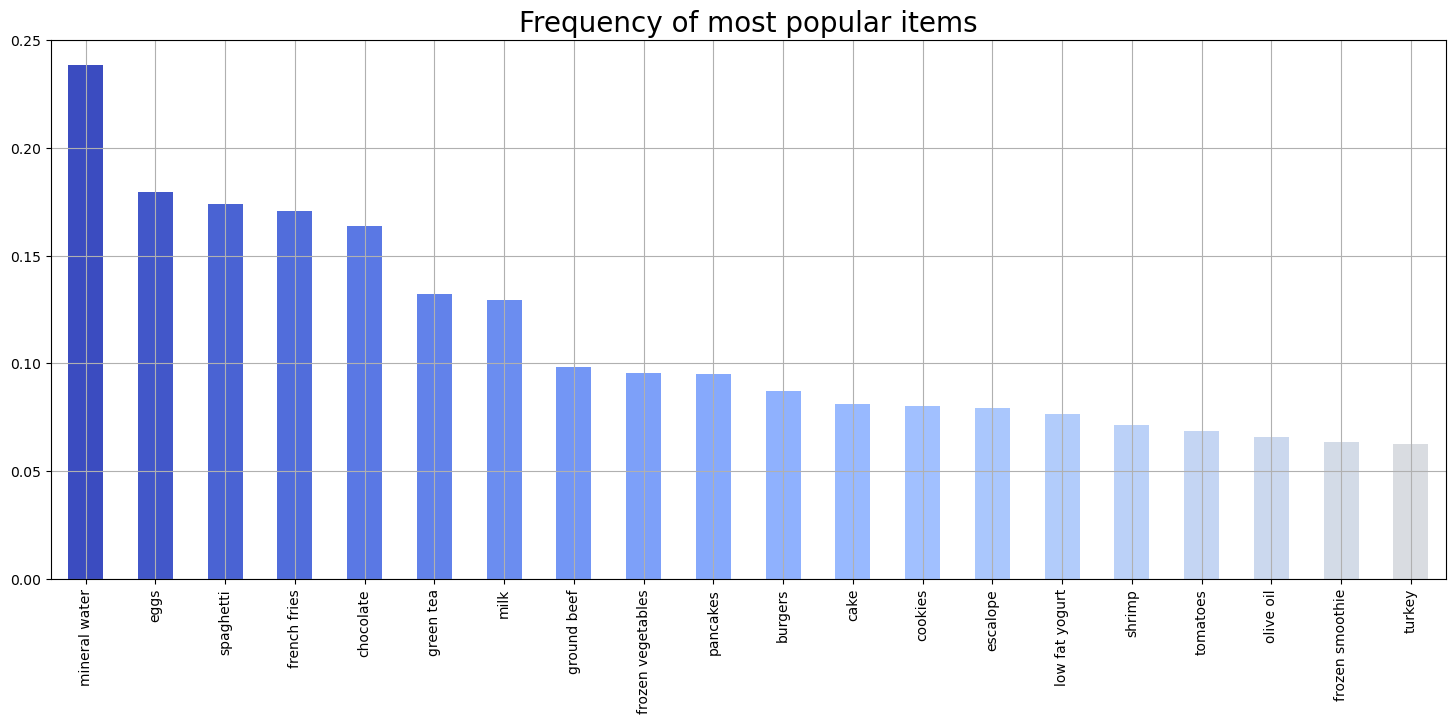

In [89]:
# استدعاء الدالة - مياه معدنية (Mineral Water) لديها أعلى نسبة ظهور
plotOccurrence(df, n=20, title='Frequency of most popular items')

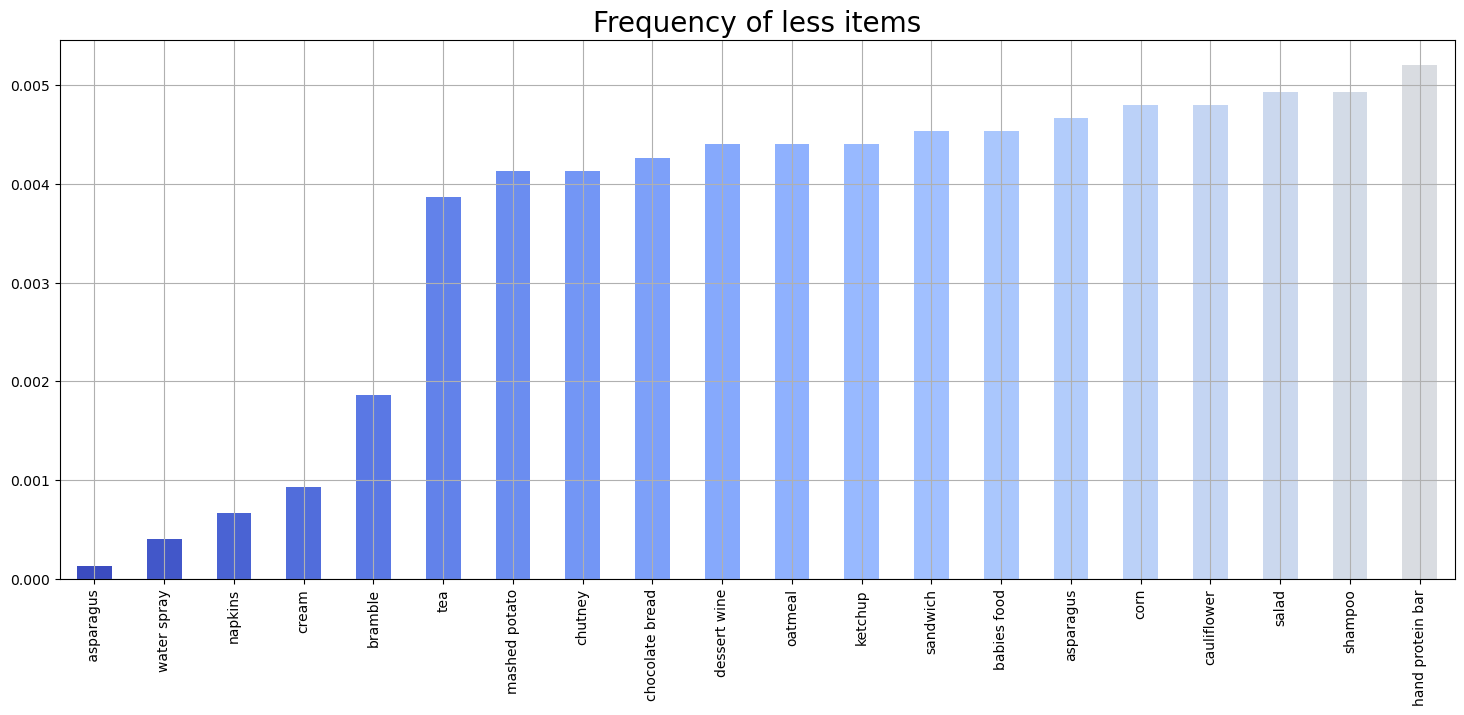

In [87]:
#يقوم بعرض المنتجات الاقل مبيعا
#يساعد صاحب الشركة على رؤية المنتجات الاقل مبيعا لعمل حملات تروجية 
#تخفيض السعر 
plotOccurrence(df, n=20, title='Frequency of less items' ,ascending=True) # Water Spray has the lowest percentage of occurrence 

In [38]:
#وظيفة هذا الكود يقوم بحساب قوة الارتباط بين المنتجات
# اكتشاف المنتجات المرتبطة معاً
# تحديد مجموعات المنتجات التي يشترها العملاء معاً
# تحسين ترتيب المنتجات في المتجر


def cramers_v(confusion_matrix):

    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

In [90]:
# وظيفة هذا الكود: إنشاء خريطة حرارية لعرض قوة الارتباط بين المنتجات
# قيمة Cramér's V | قوة الارتباط
# 0.0            | لا يوجد ارتباط
# 0.1            | ارتباط ضعيف
# 0.3            | ارتباط متوسط  
# 0.5            | ارتباط قوي
# 1.0            | ارتباط تام

def find_association(method, data, columns, plot = True, returnCorr= False):
    """
    إيجاد العلاقات بين المتغيرات المختلفة بناء على قاعدة كرامر
    """
    
    df = data  # البيانات الثنائية
    cols = columns  # قائمة المنتجات المراد تحليلها
    
    # إنشاء مصفوفة ارتباط فارغة مع تعيين القطر الرئيسي = 1 (ارتباط المنتج مع نفسه)
    corrM = np.zeros((len(cols),len(cols)))
    np.fill_diagonal(corrM, 1)

    # حساب الارتباط بين كل زوج من المنتجات
    for col1, col2 in combinations(cols, 2):  # استخدم combinations مباشرة
        idx1, idx2 = cols.index(col1), cols.index(col2)
        # إنشاء جدول طوارئ وحساب Cramér's V
        corrM[idx1, idx2] = cramers_v((pd.crosstab(df[col1], df[col2])).values)
        corrM[idx2, idx1] = corrM[idx1, idx2]  # جعل المصفوفة متماثلة

    # تحويل المصفوفة إلى DataFrame
    corr = pd.DataFrame(corrM, index=cols, columns=cols)
    
    corr = round(corr, 2)  # تقريب القيم إلى منزلتين عشريتين
    mask = np.triu(np.ones_like(corr, dtype=bool))  # إخفاء النصف العلوي المكرر
    
    if plot:
        # إنشاء الخريطة الحرارية
        fig, ax = plt.subplots(figsize=(20, 20))
        ax = sns.heatmap(corr, cmap='coolwarm', annot=True, ax=ax, mask=mask, 
                         vmax=1.0, vmin=-1.0, linewidths=0.1,
                        annot_kws={"size": 9}, square=True, cbar=True); 
        ax.set_title("Correlation between variables");
        plt.savefig("association.png", dpi = 300);  # حفظ الصورة
        plt.show()
    
    if returnCorr:
        return corr  # إرجاع مصفوفة الارتباط إذا requested

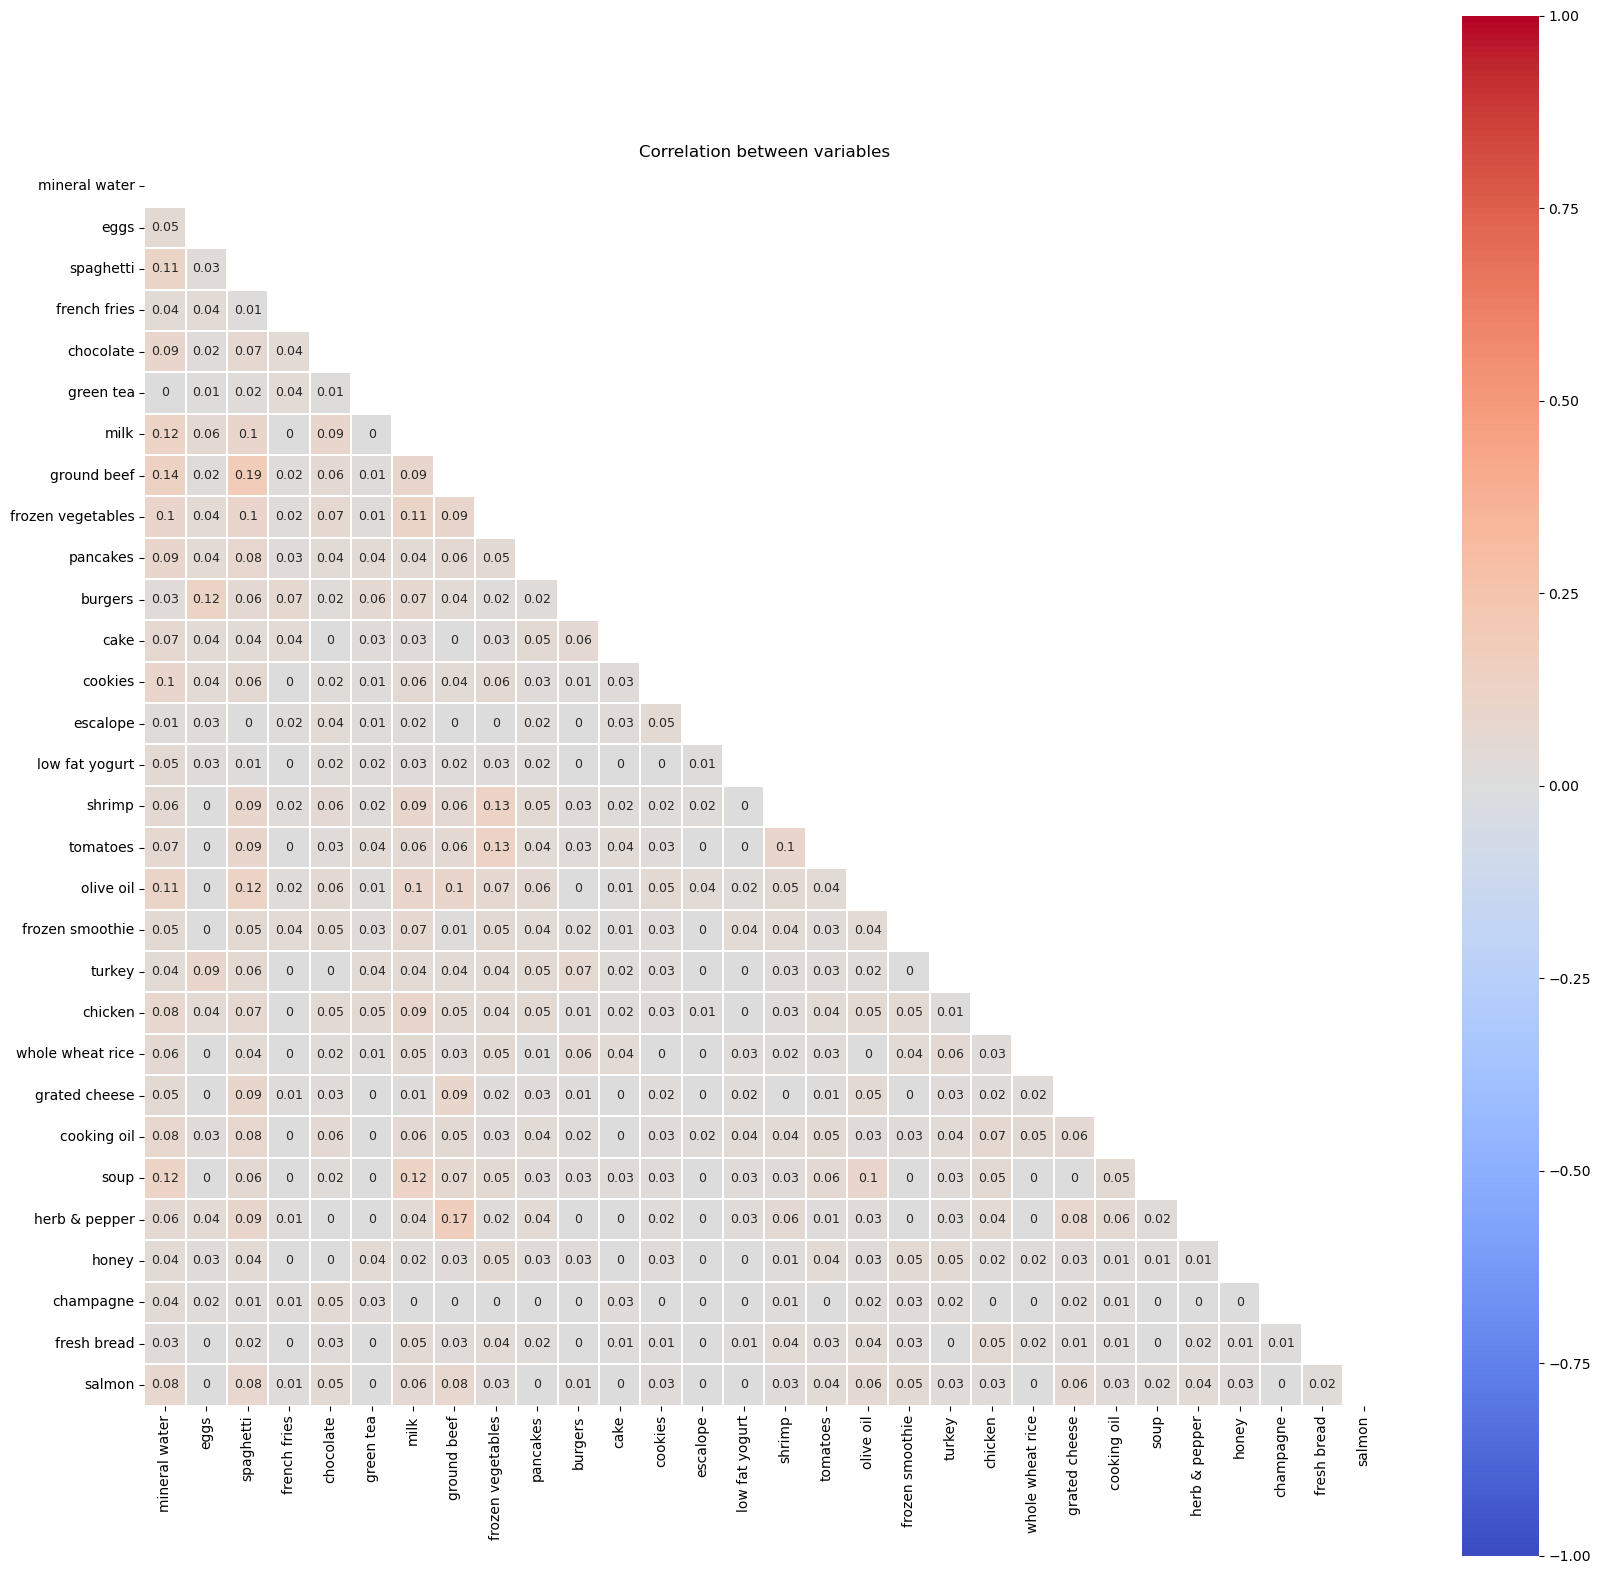

In [91]:

# وظيفة هذا الكود: تحليل الارتباط بين أهم 30 منتج من حيث الشعبية في المتجر باستخدام إحصائية 
cols = (df.sum() / df.shape[0]).sort_values(ascending=False).head(30).index.tolist()
find_association("cramers_v", df, cols)



In [92]:
#وظيفة هذا الكود يقوم بعرض الارتباطات بين المنتجات بشكل مرئي
def drawNetworkGraph(df, startNode, nCols=6):
    weightDict = {}
    cols = (df.sum() / df.shape[0]).sort_values(ascending=False).head(nCols).index.tolist()
    corrDf = find_association("cramers_v", df, cols, plot=False, returnCorr=True)
    weights = corrDf[startNode].sort_values(ascending=False)

    for key, value in zip(weights.index.tolist(), weights.values.tolist()):
        weightDict[key] = value

    combs = [x for x in itertools.combinations(weightDict.keys(), 2)]
    
    edge_width = [round(45 * corrDf[u][v], 3) for u, v in combs]
    
    G = nx.Graph()
    plt.figure(figsize=(10, 7))
    G.add_node(startNode)
    for items in weightDict.keys():
        G.add_node(items)

    for items in combs:
        G.add_edge(items[0], items[1])
    
    pos = nx.fruchterman_reingold_layout(G)

    # التصليحات: إزالة cmap وإصلاح access by position
    node_sizes = [500 * weightDict[node] for node in G.nodes()]
    
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='lightblue')
    nx.draw_networkx_edges(G, pos, width=edge_width, alpha=0.7, edge_color='gray')
    nx.draw_networkx_labels(G, pos, font_size=10)
    
    plt.axis('off')
    plt.tight_layout()

In [93]:
def getSupportData(df, min_support=0.05, length=1):
    """
    وظيفة هذا الكود: استخراج مجموعات المنتجات المتكررة التي تظهر معًا   
    """
    
    # التحويل إلى boolean داخل الدالة لحل المشكلة
    df_bool = df.astype(bool)
    
    # تطبيق خوارزمية Apriori للعثور على مجموعات المنتجات المتكررة
    frequent_itemsets = apriori(df_bool, min_support=min_support, use_colnames=True)
    
    # حساب طول كل مجموعة منتجات (عدد المنتجات في المجموعة)
    frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
    
    # ترتيب النتائج حسب الطول (الأطول أولاً) وعرض أول 3 نتائج
    frequent_itemsets.sort_values(by=['length'], ascending=False).head(3)
    
    # إرجاع المجموعات التي تطابق الطول المطلوب والدعم الأدنى
    return frequent_itemsets[(frequent_itemsets['length'] == length) & (frequent_itemsets['support'] >= min_support)]

# استدعاء الدالة للعثور على أزواج المنتجات التي تظهر معاً في 5% على الأقل من المعاملات
getSupportData(df, min_support=0.05, length=2)

#تعني عدد المنتجات المختلفة الموجودة مجموعة واحدة length 
# الهدف: اكتشاف المنتجات التي تُشترى معاً
# الفائدة: تحسين ترتيب الأرفف وعمل عروض مجمعة

# الطول	المعنى	مثال
# Length = 1	منتج فردي	(mineral water)
# Length = 2	زوج منتجات	(mineral water, spaghetti)
# Length = 3	ثلاث منتجات	(mineral water, spaghetti, eggs)
# Length = n	n منتجات	(product1, product2, ..., productn)

#هو السقف الذي نحددة لوظهور المنتجات معا min_support

,support,itemsets,length
25,0.051,"(eggs, mineral water)",2
26,0.060,"(spaghetti, mineral water)",2
27,0.053,"(mineral water, chocolate)",2


In [94]:
# . الزوج الأول: (spaghetti, mineral water)
# الدعم (0.06): ظهر هذا الزوج في 6% من عمليات الشراء
# التفسير: من كل 100 عملية شراء، هناك 6 عمليات اشتملت على المعكرونة والمياه المعدنية معًا
# التطبيق: يمكنك وضعها قريبين من بعض في المتجر

# 2. الزوج الثاني: (eggs, mineral water)
# الدعم (0.05): ظهر هذا الزوج في 5% من عمليات الشراء
# التفسير: من كل 100 عملية شراء، هناك 5 عمليات اشتملت على البيض والمياه المعدنية معًا
# التطبيق: عمل عرض "اشتري بيض واحصل على خصم على المياه"

# 3. الزوج الثالث: (mineral water, chocolate)
# الدعم (0.05): ظهر هذا الزوج في 5% من عمليات الشراء
# التفسير: من كل 100 عملية شراء، هناك 5 عمليات اشتملت على المياه المعدنية والشوكولاتة معًا
# التطبيق: يمكن عمل باقة " snack pack"



In [95]:
df = df.astype(bool) #تم استخدام هذا الكود لتحسين الاداء والسرعة

def getDataBasisMetric(df, min_support=0.02, length=2, min_threshold=0.5, metric='lift', minAntecedentLength=1, ascending=False):
    """
    استخراج قواعد الارتباط بين المنتجات بناء على مقاييس إحصائية متقدمة.
    
    Parameters:
    df: DataFrame الثنائي للمعاملات
    min_support: الحد الأدنى لنسبة تكرار مجموعة المنتجات (0-1)
    length: الطول الأولي لمجموعات المنتجات (عدد المنتجات في المجموعة)
    min_threshold: الحد الأدنى لقيمة المقياس الإحصائي
    metric: المقياس الإحصائي المستخدم (lift, confidence, support, leverage, conviction)
    minAntecedentLength: الحد الأدنى لطول الجانب الأيسر من القاعدة (عدد المنتجات في X)
    ascending: اتجاه الترتيب (True للتصاعدي، False للتنازلي)
    
    Returns:
    DataFrame يحتوي على قواعد الارتباط المفلترة والمرتبة
    """
    
    # الخطوة 1: العثور على مجموعات المنتجات المتكررة باستخدام خوارزمية Apriori
    frequent_itemsets = apriori(df, min_support=min_support, use_colnames=True)
    
    # الخطوة 2: استخراج قواعد الارتباط بناء على المقياس المحدد
    rules = association_rules(frequent_itemsets, metric=metric, min_threshold=min_threshold)
    
    # الخطوة 3: حساب طول الجانب الأيسر من كل قاعدة (عدد المنتجات في X)
    rules["antecedentLength"] = rules["antecedents"].apply(lambda x: len(x))
    
    # الخطوة 4: تصفية القواعد حسب الطول والحد الأدنى للمقياس، ثم الترتيب
    return rules[rules["antecedentLength"] >= minAntecedentLength].sort_values(by=metric, ascending=ascending)


# =============================================================================
# شرح المقاييس الإحصائية المستخدمة في القواعد:
# =============================================================================

"""
Support (الدعم): 
- نسبة المعاملات التي تحتوي على مجموعة المنتجات {X,Y}
- مثال: 0.06 يعني أن 6% من العملاء اشتروا X وY معاً

Confidence (الثقة):
- احتمال شراء Y عند شراء X
- مثال: 0.85 يعني أن 85% من الذين اشتروا X اشتروا Y أيضاً

Lift (الرفع): ⭐
- قوة الارتباط بين X وY مقارنة بالصدفة
- = 1: لا يوجد ارتباط (مستقلان)
- > 1: ارتباط إيجابي (يتواجدان معاً أكثر مما هو متوقع)
- < 1: ارتباط سلبي (يتواجدان معاً أقل مما هو متوقع)

Leverage (النفوذ):
- الفرق بين التكرار الملاحظ والمتوقع لوكان المنتجان مستقلين

Conviction (القناعة):
- قوة الاعتماد بين X وY
- قيم عالية تعني أن Y يعتمد بشدة على X
"""

# =============================================================================
# مثال التطبيق:
# =============================================================================

# العثور على قواعد ذات رفع عالي (lift >= 0.5) لمجموعات من منتجين
getDataBasisMetric(df, min_support=0.04, length=1, min_threshold=0.5, metric='lift')

# النتائج ستظهر قواعد مثل:
# {X} → {Y} (lift: 2.5, confidence: 0.8, support: 0.06)
# مما يعني: عندما يشترى X، هناك 80% chance لشراء Y، والارتفاع أعلى 2.5x من الصدفة

# def getDataBasisMetric(df, min_support=0.02, length=2, min_threshold=0.5, metric='lift', minAntecedentLength=1, ascending=False):

#     frequent_itemsets = apriori(df, min_support=min_support, use_colnames=True)
#     rules = association_rules(frequent_itemsets, metric=metric, min_threshold=min_threshold)
#     rules["antecedentLength"] = rules["antecedents"].apply(lambda x: len(x))
#     return rules[rules["antecedentLength"] >= minAntecedentLength].sort_values(by=metric, ascending=ascending)


# getDataBasisMetric(df, min_support=0.04, length=1, min_threshold=0.5, metric='lift')

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedentLength
6,(mineral water),(ground beef),0.238,0.098,0.041,0.172,1.748,1.000,0.018,1.089,0.562,0.138,0.081,0.294,1
7,(ground beef),(mineral water),0.098,0.238,0.041,0.417,1.748,1.000,0.018,1.305,0.474,0.138,0.234,0.294,1
1,(mineral water),(milk),0.238,0.130,0.048,0.201,1.554,1.000,0.017,1.090,0.468,0.150,0.082,0.286,1
0,(milk),(mineral water),0.130,0.238,0.048,0.370,1.554,1.000,0.017,1.210,0.409,0.150,0.173,0.286,1
5,(mineral water),(spaghetti),0.238,0.174,0.060,0.251,1.439,1.000,0.018,1.102,0.401,0.169,0.093,0.297,1
4,(spaghetti),(mineral water),0.174,0.238,0.060,0.343,1.439,1.000,0.018,1.159,0.369,0.169,0.137,0.297,1
9,(chocolate),(mineral water),0.164,0.238,0.053,0.321,1.348,1.000,0.014,1.122,0.309,0.151,0.109,0.271,1
8,(mineral water),(chocolate),0.238,0.164,0.053,0.221,1.348,1.000,0.014,1.073,0.339,0.151,0.068,0.271,1
2,(eggs),(mineral water),0.180,0.238,0.051,0.283,1.189,1.000,0.008,1.063,0.194,0.139,0.059,0.249,1
3,(mineral water),(eggs),0.238,0.180,0.051,0.214,1.189,1.000,0.008,1.043,0.209,0.139,0.041,0.249,1


In [96]:
# شرح أهم القواعد:
# 1. القاعدة الأقوى: {mineral water} → {ground beef}
# الثقة (0.17): 17% من الذين يشترون مياه معدنية يشترون لحم مفروم أيضاً
# الرفع (1.75): الارتباط أقوى بـ 1.75 مرة من الصدفة العشوائية ✅

# 2. القاعدة العكسية: {ground beef} → {mineral water}
# الثقة (0.42): 42% من الذين يشترون لحم مفروم يشترون مياه معدنية أيضاً
# الرفع (1.75): نفس قوة الارتباط ولكن باتجاه معاكس

# 3. أنماط الشراء الشائعة:
# الحليب والماء: 37% من مشتري الحليب يشترون مياه معدنية
# المعكرونة والماء: 34% من مشتري المعكرونة يشترون مياه معدنية
# الشوكولاتة والماء: 32% من مشتري الشوكولاتة يشترون مياه معدنية


# توصيات عملية:
# تحسين ترتيب المتجر:
# وضع المياه المعدنية قرب قسم اللحوم
# وضع المياه المعدنية بجوار الحليب والمعكرونة
# عمل ركن خاص near الشوكولاتة للمياه المعدنية

# عروض ترويجية:
# "اشتري لحم مفروم + مياه معدنية بخصم 10%"
# "عائلة من المياه المعدنية مع الحليب بسعر خاص"
# "معكرونة + مياه معدنية = عرض مشترك"




In [97]:

df = df.astype(bool)  

# وظيفة هذا الكود: تحليل وتصفية قواعد الارتباط الخاصة بمنتج معين (المياه المعدنية) وترتيبها حسب قوة الارتباط. 
# (mineral water) أي يعرض المنتجات الذي تباع مع منتج 

data = getDataBasisMetric(df, min_support=0.04, length=1, min_threshold=0.25, metric='lift')
data[data['antecedents'] == {'mineral water'}].sort_values(by=['lift'], ascending=False) # This confirms the correlation aspect.

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedentLength
6,(mineral water),(ground beef),0.238,0.098,0.041,0.172,1.748,1.000,0.018,1.089,0.562,0.138,0.081,0.294,1
1,(mineral water),(milk),0.238,0.130,0.048,0.201,1.554,1.000,0.017,1.090,0.468,0.150,0.082,0.286,1
5,(mineral water),(spaghetti),0.238,0.174,0.060,0.251,1.439,1.000,0.018,1.102,0.401,0.169,0.093,0.297,1
8,(mineral water),(chocolate),0.238,0.164,0.053,0.221,1.348,1.000,0.014,1.073,0.339,0.151,0.068,0.271,1
3,(mineral water),(eggs),0.238,0.180,0.051,0.214,1.189,1.000,0.008,1.043,0.209,0.139,0.041,0.249,1


In [98]:
# وظيفة هذا الكود: تحليل العلاقات بين المياه المعدنية والمنتجات الأخرى وترتيبها حسب الشعبية (الدعم) بدلاً من قوة الارتباط
#الهدف: معرفة أكثر المنتجات شيوعاً التي تُشترى مع المياه المعدنية

df = df.astype(bool) #تم استخدام هذا الكود لتحسين الاداء والسرعة

data = getDataBasisMetric(df, min_support=0.04, length=1, min_threshold=0.25, metric='lift')
data[data['antecedents'] == {'mineral water'}].sort_values(by=['support'], ascending=False) # This confirms the correlation aspect.

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedentLength
5,(mineral water),(spaghetti),0.238,0.174,0.060,0.251,1.439,1.000,0.018,1.102,0.401,0.169,0.093,0.297,1
8,(mineral water),(chocolate),0.238,0.164,0.053,0.221,1.348,1.000,0.014,1.073,0.339,0.151,0.068,0.271,1
3,(mineral water),(eggs),0.238,0.180,0.051,0.214,1.189,1.000,0.008,1.043,0.209,0.139,0.041,0.249,1
1,(mineral water),(milk),0.238,0.130,0.048,0.201,1.554,1.000,0.017,1.090,0.468,0.150,0.082,0.286,1
6,(mineral water),(ground beef),0.238,0.098,0.041,0.172,1.748,1.000,0.018,1.089,0.562,0.138,0.081,0.294,1


In [99]:
#وظييفة هذا الكود : عرض المنتجات من حيث قوة الموثقية

df = df.astype(bool)  

getDataBasisMetric(df, min_support=0.05, length=1, min_threshold=0.3, metric='confidence')

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedentLength
0,(spaghetti),(mineral water),0.174,0.238,0.060,0.343,1.439,1.000,0.018,1.159,0.369,0.169,0.137,0.297,1
1,(chocolate),(mineral water),0.164,0.238,0.053,0.321,1.348,1.000,0.014,1.122,0.309,0.151,0.109,0.271,1


In [100]:
# وظيفة هذا الكود : يفحص ويؤكد هل النتائج السابقة صحيحة ام صدفة
# يصنع جدول طوارئ يظهر توزيع الشراء بين المنتجين
# يحسب القيم المتوقعة لو كان المنتجان مستقلين
# يقرر إذا كان الارتباط حقيقي أم صدفة


def buildContingency(df, antecedant, precedant):
    data_crosstab = pd.crosstab(df[antecedant], df[precedant], rownames = [antecedant.upper()],
                                colnames=[precedant.upper()], margins = True)
    
    print("\nPivot :")
    print(data_crosstab)
    
    crosstab, resChi , expected = researchpy.crosstab(df[antecedant], df[precedant], 
                                                      test= "chi-square", expected_freqs= True);
    
    print('\nExpected Values')
    print(expected)
    
    print("\nPearson Chi-square :", round(resChi.values[0][1], 3))
    

In [101]:
df = df.astype(bool) #تم استخدام هذا الكود لتحسين الاداء والسرعة

getDataBasisMetric(df, min_support=0.05, length=1, min_threshold=0.3, metric='confidence')
buildContingency(df, antecedant = 'mineral water', precedant = 'ground beef')   


Pivot :
GROUND BEEF    False  True   All
MINERAL WATER                   
False           5283   430  5713
True            1481   307  1788
All             6764   737  7501

Expected Values
              ground beef        
ground beef         False   True 
mineral water                    
False           5,151.677 561.323
True            1,612.323 175.677

Pearson Chi-square : 142.933


C:\ProgramData\anaconda3\Lib\site-packages\researchpy\crosstab.py:146: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Pearson Chi-square ( 1.0) = ' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.iloc[0,0] = f"Pearson Chi-square ({dof: .1f}) = "


In [102]:
#  الجدول الملاحظ (Pivot Table):
#430: عملاء اشتروا مياه معدنية بدون لحم مفروم
# 307: عملاء اشتروا كلا المنتجين معًا ✅
# 1481: عملاء اشتروا لحم مفروم بدون مياه معدنية
# 5283: عملاء لم يشتروا أي من المنتجين

#الجدول المتوقع (Expected Values):
# المقارنة الحاسمة:
# ملاحظ: 307 (اشتروا كلا المنتجين)
# متوقع: 175.68 (لو كانا مستقلين)
# الفرق: +131.32 ← ارتباط قوي! 🎯

# اختبار Pearson Chi-square:
# التفسير الإحصائي:
# القيمة الحرجة (0.05): ≈ 3.84
# نتيجة الاختبار: 142.933 > 3.84
# الاستنتاج: ارتباط ذو دلالة إحصائية عالية جدًا ✅

# التحليل العملي:
# معدلات الشراء:
# مشترو المياه فقط: 430 / 5713 = 7.5%
# مشترو اللحم فقط: 1481 / 1788 = 82.8%
# مشترو كليهما: 307 / 1788 = 17.2% ← نسبة مهمة

In [103]:

buildContingency(df, antecedant = 'mineral water', precedant = 'spaghetti')   


Pivot :
SPAGHETTI      False  True   All
MINERAL WATER                   
False           4855   858  5713
True            1340   448  1788
All             6195  1306  7501

Expected Values
              spaghetti        
spaghetti         False   True 
mineral water                  
False         4,718.309 994.691
True          1,476.691 311.309

Pearson Chi-square : 95.416


C:\ProgramData\anaconda3\Lib\site-packages\researchpy\crosstab.py:146: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Pearson Chi-square ( 1.0) = ' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.iloc[0,0] = f"Pearson Chi-square ({dof: .1f}) = "


In [104]:
# # وظيفة هذا الكود: تقييم جودة وتوازن قواعد الارتباط باستخدام مقياسين إحصائيين متقدمين. 
# def validateMetric(df, antecedents, consequents, min_support=0.01, length=1, min_threshold=0.01, metric='lift'):

#     data = getDataBasisMetric(df, min_support=0.01, length=1, min_threshold=0.01, metric='lift')
#     PA = data[(data['antecedents'] == {antecedents}) & (data['consequents'] == {consequents})]

#     kulczynski = round(0.5 * PA['support'].values[0] * \
#                        ((1/PA['antecedent support'].values[0]) + (1/PA['consequent support'].values[0])), 4)

#     IR = round((PA['antecedent support'].values[0] - PA['consequent support'].values[0])/ \
#     (PA['antecedent support'].values[0] + PA['consequent support'].values[0] - PA['support'].values[0]) , 3)
    
#     print(f"Kulczynski : {kulczynski} ; Imbalance Ratio : {IR}")


In [105]:
# validateMetric(df, antecedents='mineral water', consequents='ground beef', 
#                min_support=0.01, length=1, min_threshold=0.5, metric='lift')

In [106]:
# validateMetric(df, antecedents='mineral water', consequents='spaghetti', 
#                min_support=0.01, length=1, min_threshold=0.5, metric='lift')

# # Higher Balance as ratio is closer to 0.